# OrcaFlex natuurlijke periode: heave, pitch en roll

Dit notebook voert per vrijheidsgraad een free-decay analyse uit:

1. Model laden.
2. Alleen één initiële excitatie zetten: heave, pitch of roll.
3. Simulatie draaien.
4. Tijdsignaal uitlezen.
5. Positieve pieken detecteren.
6. Natuurlijke periode bepalen uit de afstand tussen pieken.

Controleer eerst de paden en objectnamen in de configuratiecel.

## 1. Imports

In [25]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

import OrcFxAPI

## 2. Configuratie

Pas vooral `MODEL_PATH`, `OUTPUT_DIR`, `VESSEL_NAME`, `VESSEL_TYPE_NAME` en de excitatie-amplitudes in `DOF_CONFIGS` aan wanneer nodig.

In [26]:
MODEL_PATH = Path(r"C:\\Users\\verav\\Desktop\\Studie\\Afstuderen\\PHASE2_ORCA\\Merganserfinal_decay.dat")
OUTPUT_DIR = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Merganser\Merganser_tryoutsimulations")
PLOTS_DIR = OUTPUT_DIR / "plots"
TABLES_DIR = OUTPUT_DIR / "tables"

SUMMARY_EXCEL_PATH = TABLES_DIR / "natural_periods_heave_pitch_roll.xlsx"
SUMMARY_CSV_PATH = TABLES_DIR / "natural_periods_heave_pitch_roll.csv"

# OrcaFlex object names from your supplied notebook
VESSEL_NAME = "floaters"
VESSEL_TYPE_NAME = "floatertype"


# Keep this False if your .dat file is already prepared with no waves/current.
# Set True only if you want the script to try to disable waves/current automatically.
TRY_DISABLE_WAVES_AND_CURRENT = False

# Set True if you want to remove the vessel type's "Other damping" terms.
# This follows the approach in your reference notebook.
ZERO_OTHER_DAMPING = True

# Added-mass / aero-added-mass correction object settings.
# These are copied from your roll notebook. Adjust as needed.
# If you do not want the script to touch this object, set SET_AERO_ADDED_MASS = False.
SET_AERO_ADDED_MASS = False


# Time window used to calculate the period from the simulated decay signal.
PERIOD_T_MIN = 0.0
PERIOD_T_MAX = 80.0
PERIOD_SKIP_FIRST_PEAK = True

# Simulation end time override. Set to None to use the model settings.
# If your model simulation is too short, set for example SIMULATION_DURATION = 120.0.
SIMULATION_DURATION = None

# Plot format
FIGSIZE = (16, 7)
DPI = 200
TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 14
LEGEND_SIZE = 12


@dataclass(frozen=True)
class DofConfig:
    name: str
    initial_attribute: str
    initial_amplitude: float
    time_history_candidates: tuple[str, ...]
    ylabel: str
    prominence: float | None


# Initial excitations.
# Use small amplitudes to stay close to the linear natural period.
DOF_CONFIGS = [
    DofConfig(
        name="heave",
        initial_attribute="InitialZ",
        initial_amplitude=4.0,  # m
        time_history_candidates=("Z", "Heave", "Dynamic z", "Position z"),
        ylabel="Heave [m]",
        prominence=0.02,
    ),
    DofConfig(
        name="pitch",
        initial_attribute="InitialTrim",
        initial_amplitude=7.0,  # deg
        time_history_candidates=("Rotation 2", "Pitch", "Trim"),
        ylabel="Pitch [deg]",
        prominence=0.05,
    ),
    DofConfig(
        name="roll",
        initial_attribute="InitialHeel",
        initial_amplitude=7.0,  # deg
        time_history_candidates=("Rotation 1", "Roll", "Heel"),
        ylabel="Roll [deg]",
        prominence=0.05,
    ),
]

## 3. Helperfuncties

In [27]:
def safe_setattr(obj, attr_name: str, value) -> bool:
    """Set an OrcaFlex attribute if it exists/accepts the value."""
    try:
        setattr(obj, attr_name, value)
        return True
    except Exception:
        return False


def try_time_history(obj, candidate_names: Iterable[str]) -> tuple[str, np.ndarray]:
    """Return the first available time-history result from a list of candidates."""
    errors = []
    for name in candidate_names:
        try:
            values = np.asarray(obj.TimeHistory(name), dtype=float)
            return name, values
        except Exception as exc:
            errors.append(f"{name}: {exc}")

    msg = "Could not read any of these OrcaFlex time histories: " + ", ".join(candidate_names)
    msg += "\nTried:\n" + "\n".join(errors)
    raise RuntimeError(msg)


def set_all_initial_offsets_zero(vessel) -> None:
    """Reset common vessel initial position/rotation attributes to zero."""
    initial_attrs = [
        "InitialX",
        "InitialY",
        "InitialZ",
        "InitialHeel",
        "InitialTrim",
        "InitialHeading",
    ]
    for attr in initial_attrs:
        safe_setattr(vessel, attr, 0.0)


def set_single_dof_excitation(vessel, dof: DofConfig) -> None:
    """Apply only one initial offset/rotation to excite one mode."""
    set_all_initial_offsets_zero(vessel)
    if not safe_setattr(vessel, dof.initial_attribute, float(dof.initial_amplitude)):
        raise AttributeError(f"Could not set vessel.{dof.initial_attribute}")


def set_all_viscous_damping_to_zero(vesseltype) -> None:
    """Disable OrcaFlex vessel type 'Other damping' terms where available."""
    damping_attributes = [
        "OtherDampingLinearCoeffx", "OtherDampingQuadraticCoeffx",
        "OtherDampingLinearCoeffy", "OtherDampingQuadraticCoeffy",
        "OtherDampingLinearCoeffz", "OtherDampingQuadraticCoeffz",
        "OtherDampingLinearCoeffRx", "OtherDampingQuadraticCoeffRx",
        "OtherDampingLinearCoeffRy", "OtherDampingQuadraticCoeffRy",
        "OtherDampingLinearCoeffRz", "OtherDampingQuadraticCoeffRz",
    ]
    for attr in damping_attributes:
        safe_setattr(vesseltype, attr, 0.0)





def try_disable_waves_and_current(model) -> None:
    """
    Best-effort no-wave/no-current settings.

    This is intentionally conservative: all assignments are attempted and ignored
    if they do not match your OrcaFlex version/model. Always verify the .dat file.
    """
    env = model.environment

    # Common wave-related possibilities.
    for attr, value in [
        ("WaveType", "None"),
        ("WaveHs", 0.0),
        ("WaveH", 0.0),
        ("WaveHeight", 0.0),
    ]:
        safe_setattr(env, attr, value)

    # Common current-related possibilities.
    for attr, value in [
        ("CurrentMethod", "None"),
        ("RefCurrentSpeed", 0.0),
        ("CurrentSpeedAtSurface", 0.0),
    ]:
        safe_setattr(env, attr, value)


def set_simulation_duration_if_requested(model, duration: float | None) -> None:
    """Optionally override the simulation duration."""
    if duration is None:
        return

    # OrcaFlex models differ in how stages are configured. Try common options.
    general = model.general
    for attr in ["StageDuration", "ImplicitConstantTimeStep"]:
        # Do not alter time step here; placeholder to keep function explicit.
        pass

    # Most robust simple attempt: set stage duration if model exposes it.
    # If this fails, change the simulation duration in the .dat file instead.
    if not safe_setattr(general, "StageDuration", [float(duration)]):
        if not safe_setattr(general, "StageDuration", float(duration)):
            print("Warning: could not override simulation duration. Using .dat model settings.")

## 4. Periode bepalen uit positieve pieken

In [28]:
def calculate_period_from_positive_peaks(
    time: np.ndarray,
    signal: np.ndarray,
    prominence: float | None = None,
    t_min: float = 0.0,
    t_max: float | None = None,
    skip_first_peak: bool = True,
) -> dict:
    """Calculate mean period from consecutive positive peaks."""
    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)

    mask = np.isfinite(time) & np.isfinite(signal) & (time >= t_min)
    if t_max is not None:
        mask &= time <= t_max

    t_win = time[mask]
    z_win = signal[mask]

    if len(t_win) < 3:
        return {
            "period_s": np.nan,
            "n_peaks_used": 0,
            "peak_times_s": np.array([]),
            "peak_values": np.array([]),
            "periods_s": np.array([]),
        }

    if prominence is None:
        peak_idx, _ = find_peaks(z_win)
    else:
        peak_idx, _ = find_peaks(z_win, prominence=prominence)

    if skip_first_peak and len(peak_idx) > 2:
        peak_idx = peak_idx[1:]

    peak_times = t_win[peak_idx]
    peak_values = z_win[peak_idx]

    if len(peak_times) < 2:
        period = np.nan
        periods = np.array([])
    else:
        periods = np.diff(peak_times)
        periods = periods[np.isfinite(periods)]
        period = float(np.mean(periods)) if len(periods) else np.nan

    return {
        "period_s": period,
        "n_peaks_used": int(len(peak_times)),
        "peak_times_s": peak_times,
        "peak_values": peak_values,
        "periods_s": periods,
    }

## 5. OrcaFlex simulatie per DOF

In [29]:
def run_one_decay(model_path: Path, dof: DofConfig) -> dict:
    """Run one OrcaFlex free-decay simulation for one DOF."""
    model = OrcFxAPI.Model(str(model_path))
    vessel = model[VESSEL_NAME]
    vesseltype = model[VESSEL_TYPE_NAME]

    if TRY_DISABLE_WAVES_AND_CURRENT:
        try_disable_waves_and_current(model)

    if SET_AERO_ADDED_MASS:
        set_aero_added_mass(model, AERO_ADDED_MASS_VALUES)

    if ZERO_OTHER_DAMPING:
        set_all_viscous_damping_to_zero(vesseltype)

    set_simulation_duration_if_requested(model, SIMULATION_DURATION)
    set_single_dof_excitation(vessel, dof)

    print(f"Running {dof.name} decay with {dof.initial_attribute} = {dof.initial_amplitude} ...")
    model.RunSimulation()

    time = np.asarray(model.general.TimeHistory("Time"), dtype=float)
    time = time - time[0]

    result_name, signal = try_time_history(vessel, dof.time_history_candidates)
    signal = np.asarray(signal, dtype=float)

    period_info = calculate_period_from_positive_peaks(
        time=time,
        signal=signal,
        prominence=dof.prominence,
        t_min=PERIOD_T_MIN,
        t_max=PERIOD_T_MAX,
        skip_first_peak=PERIOD_SKIP_FIRST_PEAK,
    )

    return {
        "dof": dof.name,
        "initial_attribute": dof.initial_attribute,
        "initial_amplitude": dof.initial_amplitude,
        "time_history_name": result_name,
        "time_s": time,
        "signal": signal,
        **period_info,
    }

## 6. Plot- en outputfuncties

In [30]:
def plot_decay(result: dict, dof: DofConfig, save_dir: Path) -> Path:
    """Save one decay plot with detected positive peaks."""
    save_dir.mkdir(parents=True, exist_ok=True)

    t = result["time_s"]
    z = result["signal"]
    peak_times = result["peak_times_s"]
    peak_values = result["peak_values"]

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(t, z, linewidth=2.3, label="Simulation free decay")

    if len(peak_times):
        ax.scatter(peak_times, peak_values, s=55, marker="o", label="Positive peaks used/found")

    ax.scatter(
        [0.0],
        [dof.initial_amplitude],
        s=220,
        marker="x",
        linewidths=3.5,
        label="Initial excitation",
    )

    period = result["period_s"]
    period_text = f"{period:.3f} s" if np.isfinite(period) else "not found"

    ax.set_title(
        f"Free-decay natural period - {dof.name}\n"
        f"Result: {result['time_history_name']} | Natural period: {period_text}",
        fontsize=TITLE_SIZE,
    )
    ax.set_xlabel("Time [s]", fontsize=LABEL_SIZE)
    ax.set_ylabel(dof.ylabel, fontsize=LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.grid(True)
    ax.legend(fontsize=LEGEND_SIZE)
    fig.tight_layout()

    out_path = save_dir / f"natural_period_{dof.name}.png"
    fig.savefig(out_path, dpi=DPI)
    plt.close(fig)
    return out_path


def main() -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    TABLES_DIR.mkdir(parents=True, exist_ok=True)

    all_results = []
    plot_paths = []

    for dof in DOF_CONFIGS:
        result = run_one_decay(MODEL_PATH, dof)
        plot_path = plot_decay(result, dof, PLOTS_DIR)
        plot_paths.append(plot_path)
        all_results.append(result)

        period = result["period_s"]
        period_text = f"{period:.3f} s" if np.isfinite(period) else "not found"
        print(f"{dof.name}: period = {period_text}, peaks used = {result['n_peaks_used']}")

    summary_rows = []
    for result, plot_path in zip(all_results, plot_paths):
        periods = result["periods_s"]
        summary_rows.append({
            "dof": result["dof"],
            "initial_attribute": result["initial_attribute"],
            "initial_amplitude": result["initial_amplitude"],
            "time_history_name": result["time_history_name"],
            "period_s": result["period_s"],
            "period_std_s": float(np.std(periods, ddof=1)) if len(periods) > 1 else np.nan,
            "n_peaks_used": result["n_peaks_used"],
            "period_t_min_s": PERIOD_T_MIN,
            "period_t_max_s": PERIOD_T_MAX,
            "skip_first_peak": PERIOD_SKIP_FIRST_PEAK,
            "prominence": next(d.prominence for d in DOF_CONFIGS if d.name == result["dof"]),
            "model_path": str(MODEL_PATH),
            "plot_path": str(plot_path),
        })

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_excel(SUMMARY_EXCEL_PATH, index=False)
    summary_df.to_csv(SUMMARY_CSV_PATH, index=False)

    print("\nSaved summary:")
    print(SUMMARY_EXCEL_PATH)
    print(SUMMARY_CSV_PATH)
    print("\nSaved plots:")
    for path in plot_paths:
        print(path)

    print("\nSummary:")
    print(summary_df[["dof", "period_s", "period_std_s", "n_peaks_used", "time_history_name"]])


## 7. Analyse uitvoeren

In [31]:
# Run alle free-decay analyses
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

all_results = []
plot_paths = []

for dof in DOF_CONFIGS:
    result = run_one_decay(MODEL_PATH, dof)
    plot_path = plot_decay(result, dof, PLOTS_DIR)
    plot_paths.append(plot_path)
    all_results.append(result)

    period = result["period_s"]
    period_text = f"{period:.3f} s" if np.isfinite(period) else "not found"
    print(f"{dof.name}: period = {period_text}, peaks used = {result['n_peaks_used']}")

summary_rows = []
for result, plot_path in zip(all_results, plot_paths):
    periods = result["periods_s"]
    summary_rows.append({
        "dof": result["dof"],
        "initial_attribute": result["initial_attribute"],
        "initial_amplitude": result["initial_amplitude"],
        "time_history_name": result["time_history_name"],
        "period_s": result["period_s"],
        "period_std_s": float(np.std(periods, ddof=1)) if len(periods) > 1 else np.nan,
        "n_peaks_used": result["n_peaks_used"],
        "period_t_min_s": PERIOD_T_MIN,
        "period_t_max_s": PERIOD_T_MAX,
        "skip_first_peak": PERIOD_SKIP_FIRST_PEAK,
        "prominence": next(d.prominence for d in DOF_CONFIGS if d.name == result["dof"]),
        "model_path": str(MODEL_PATH),
        "plot_path": str(plot_path),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_excel(SUMMARY_EXCEL_PATH, index=False)
summary_df.to_csv(SUMMARY_CSV_PATH, index=False)

print("\nSaved summary:")
print(SUMMARY_EXCEL_PATH)
print(SUMMARY_CSV_PATH)
print("\nSaved plots:")
for path in plot_paths:
    print(path)

summary_df[["dof", "period_s", "period_std_s", "n_peaks_used", "time_history_name"]]

Running heave decay with InitialZ = 4.0 ...
heave: period = 4.078 s, peaks used = 10
Running pitch decay with InitialTrim = 7.0 ...
pitch: period = 7.100 s, peaks used = 5
Running roll decay with InitialHeel = 7.0 ...
roll: period = 7.075 s, peaks used = 5

Saved summary:
C:\Users\verav\Desktop\Studie\Afstuderen\Merganser\Merganser_tryoutsimulations\tables\natural_periods_heave_pitch_roll.xlsx
C:\Users\verav\Desktop\Studie\Afstuderen\Merganser\Merganser_tryoutsimulations\tables\natural_periods_heave_pitch_roll.csv

Saved plots:
C:\Users\verav\Desktop\Studie\Afstuderen\Merganser\Merganser_tryoutsimulations\plots\natural_period_heave.png
C:\Users\verav\Desktop\Studie\Afstuderen\Merganser\Merganser_tryoutsimulations\plots\natural_period_pitch.png
C:\Users\verav\Desktop\Studie\Afstuderen\Merganser\Merganser_tryoutsimulations\plots\natural_period_roll.png


,dof,period_s,period_std_s,n_peaks_used,time_history_name
0,heave,4.077778,4.409586e-02,10,Z
1,pitch,7.100000,1.776357e-15,5,Rotation 2
2,roll,7.075000,5.000000e-02,5,Rotation 1


## 8. Plots tonen

natural_period_heave.png


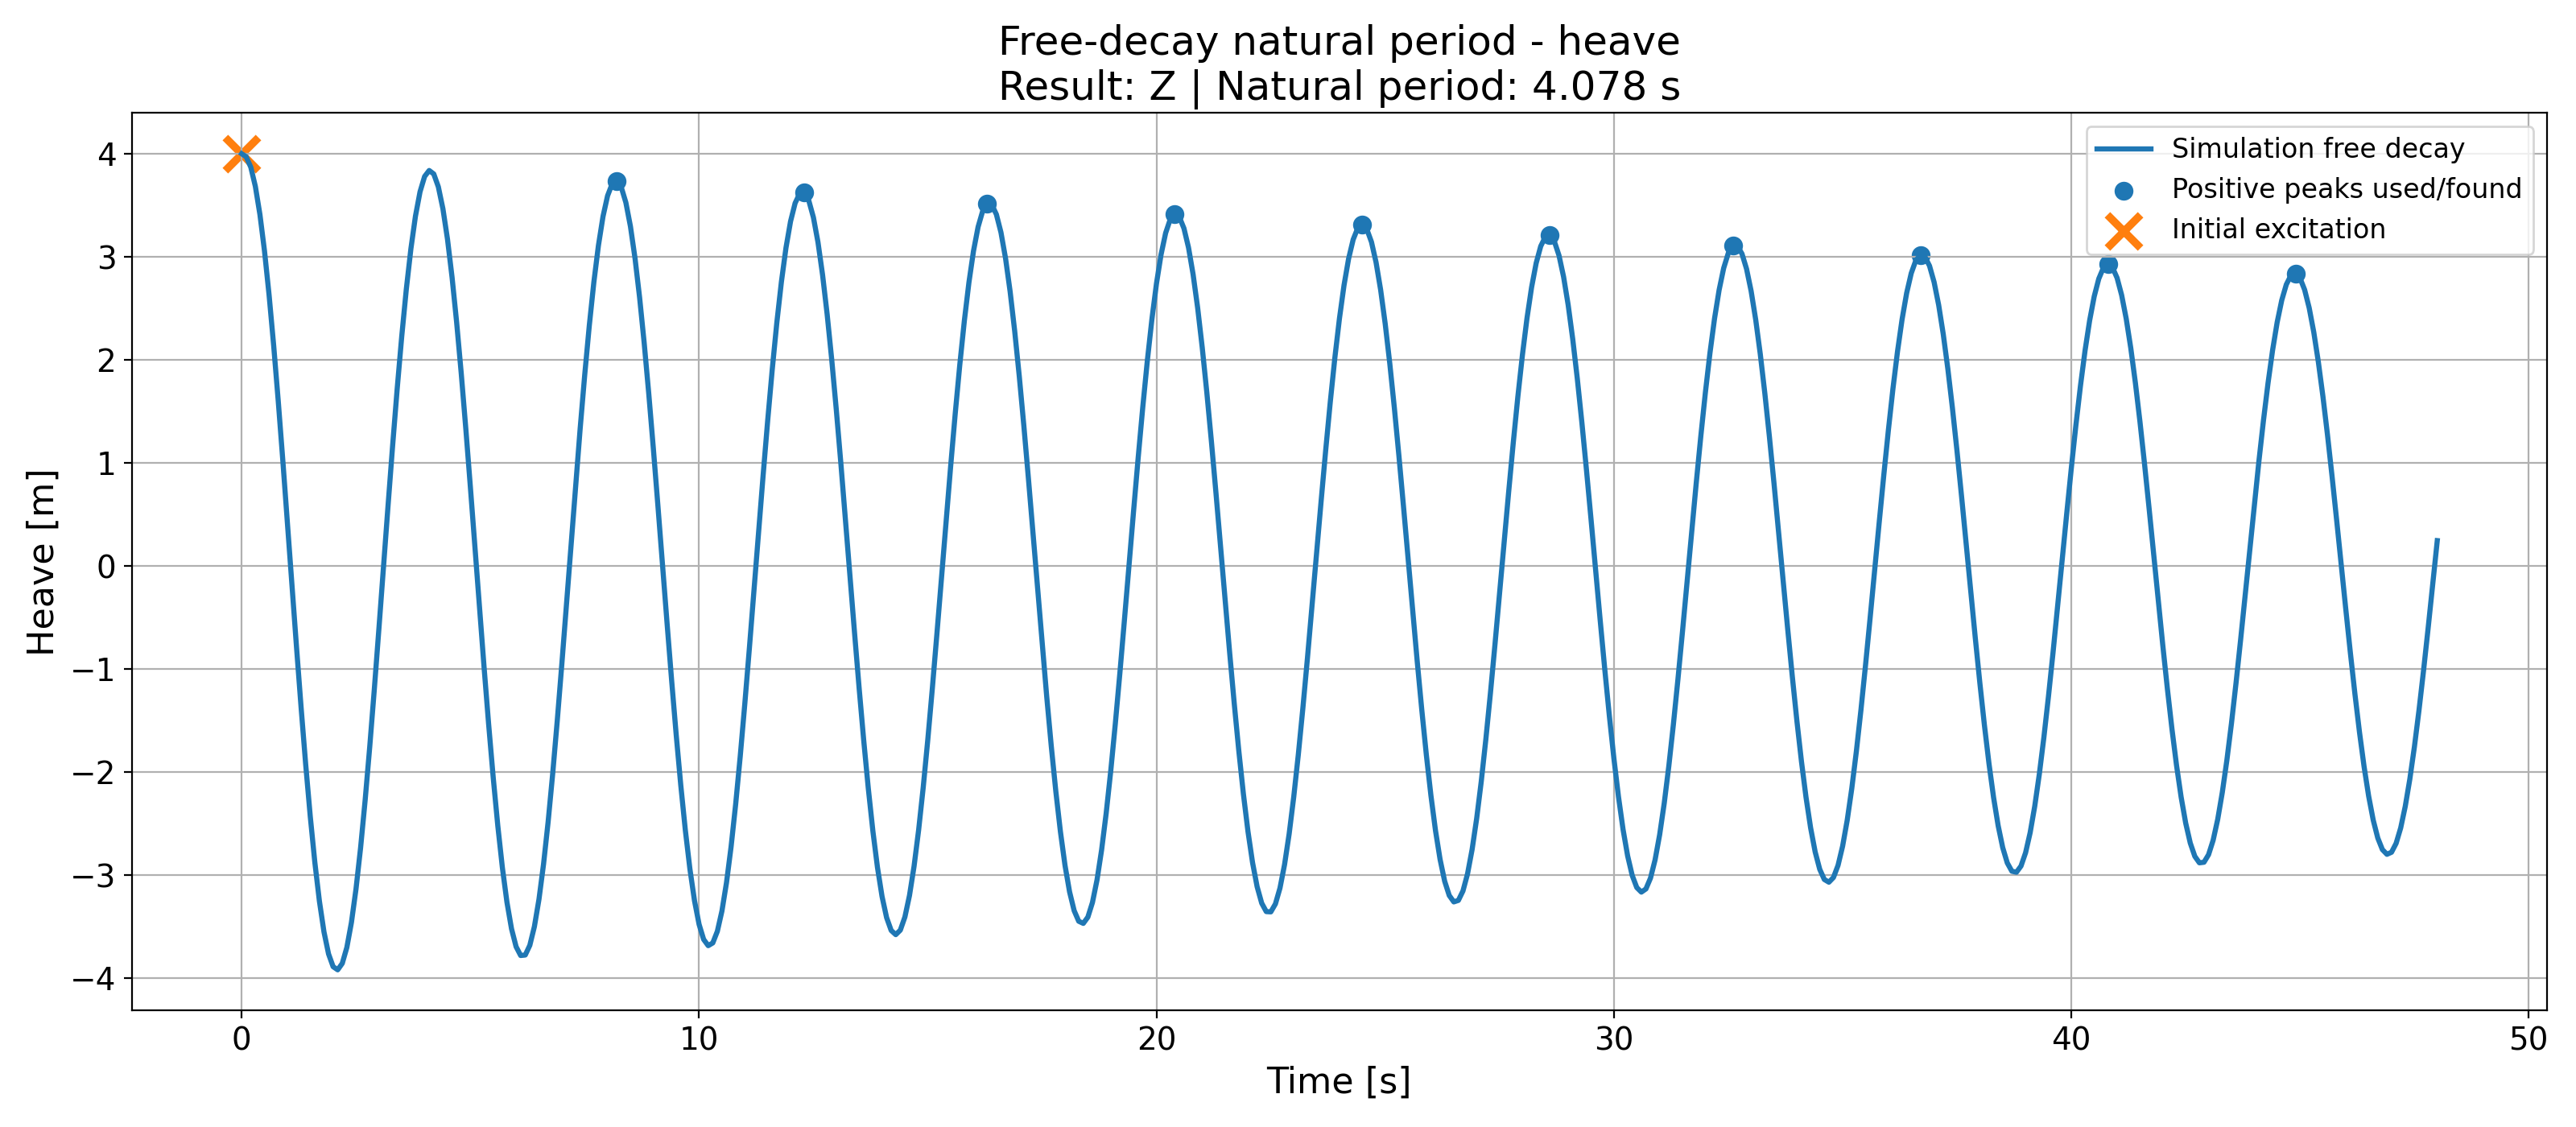

natural_period_pitch.png


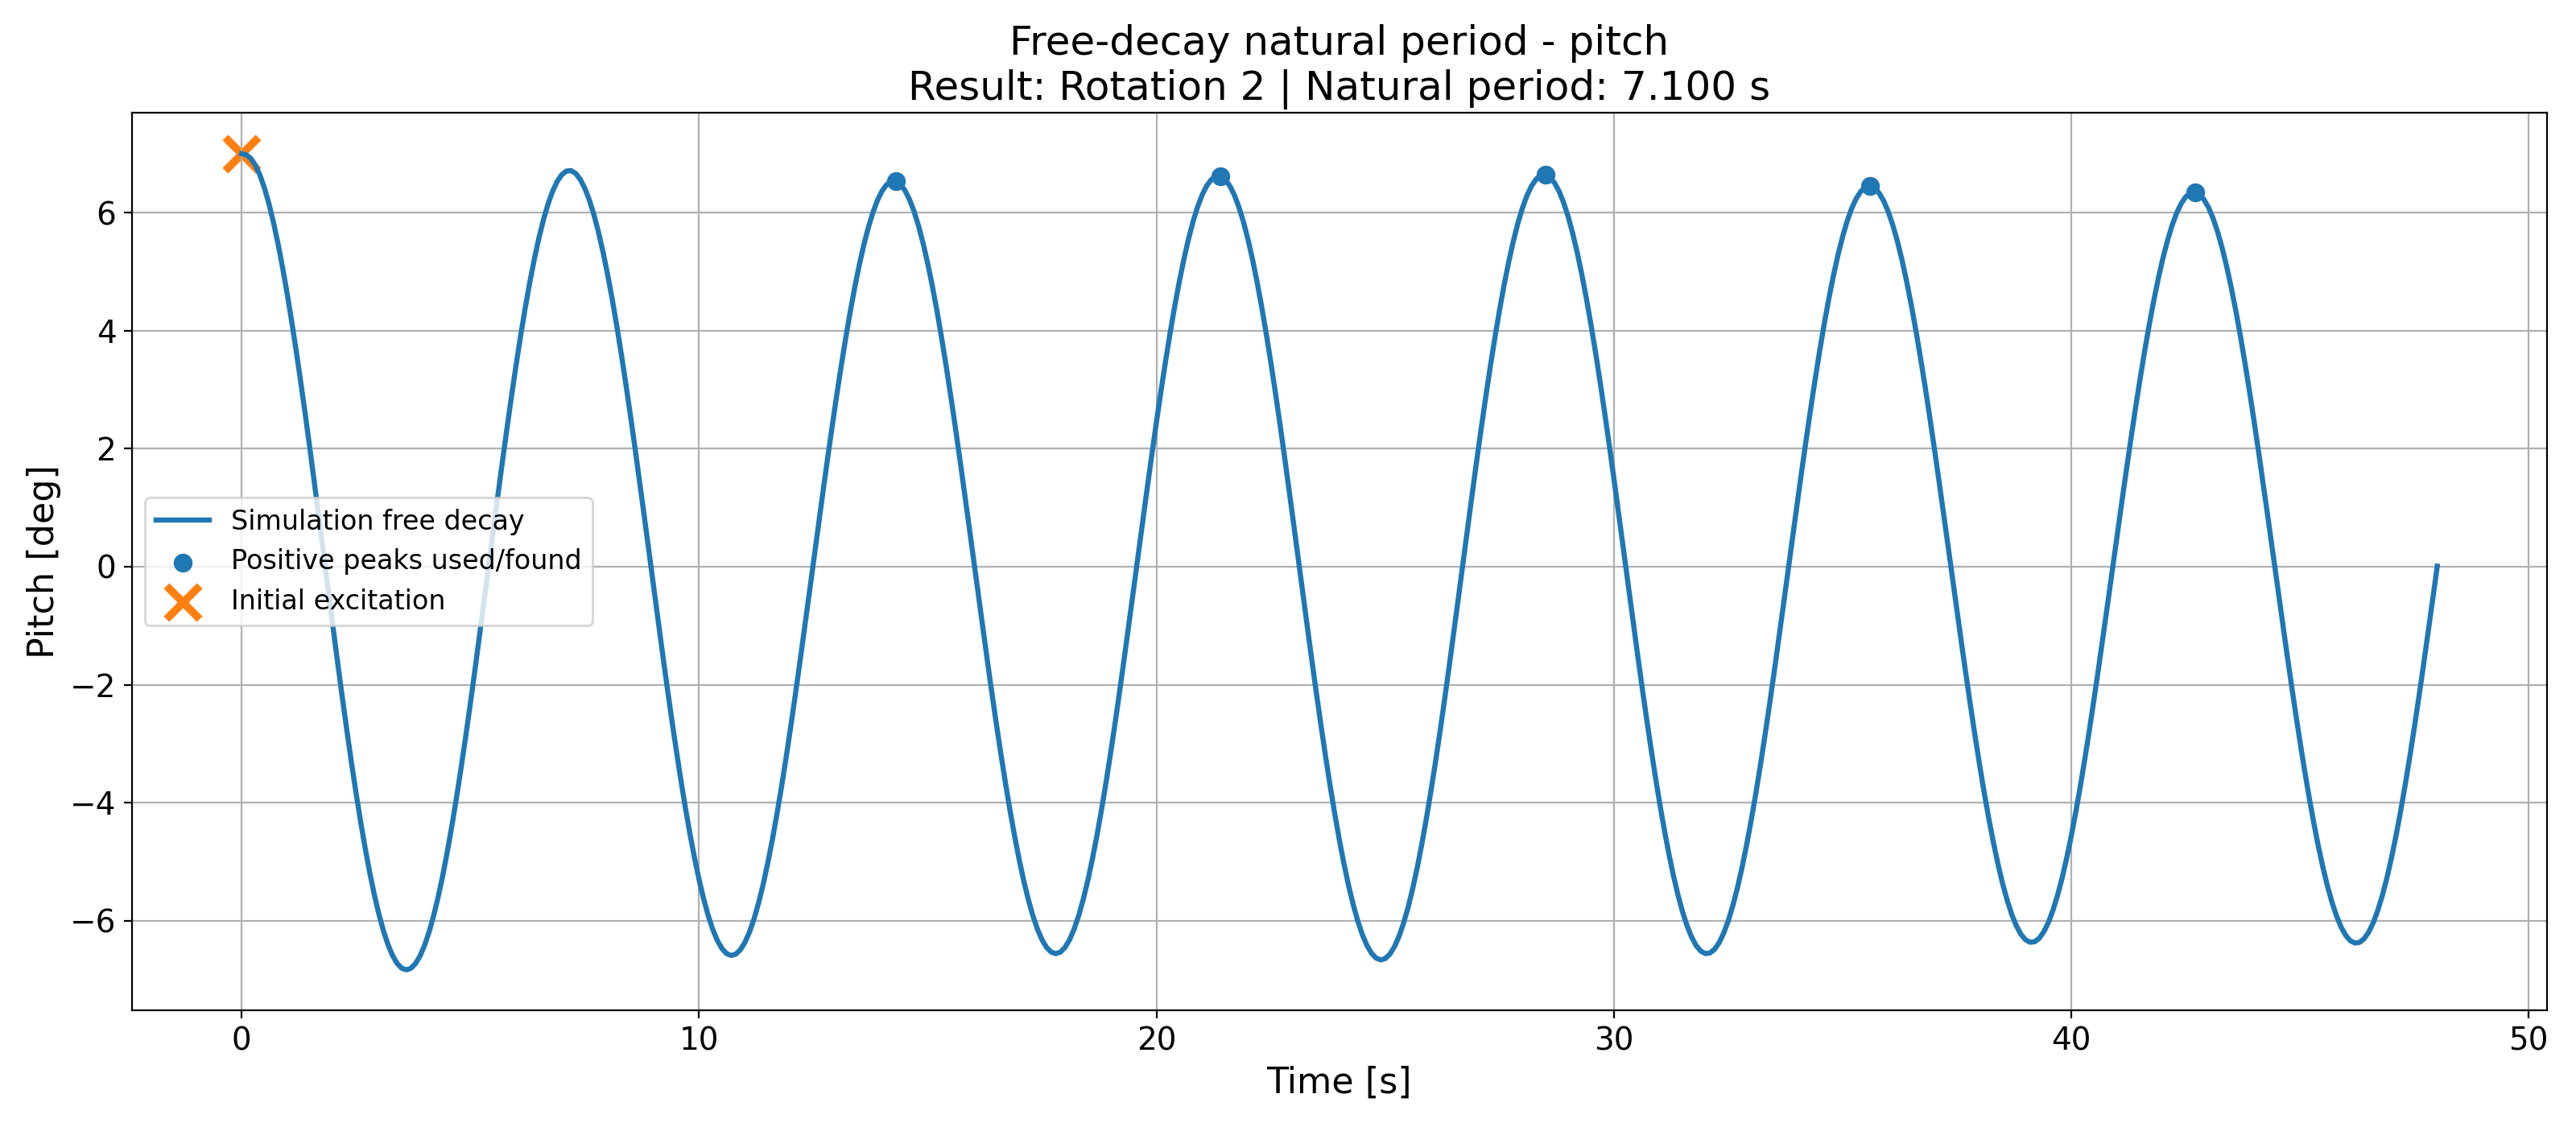

natural_period_roll.png


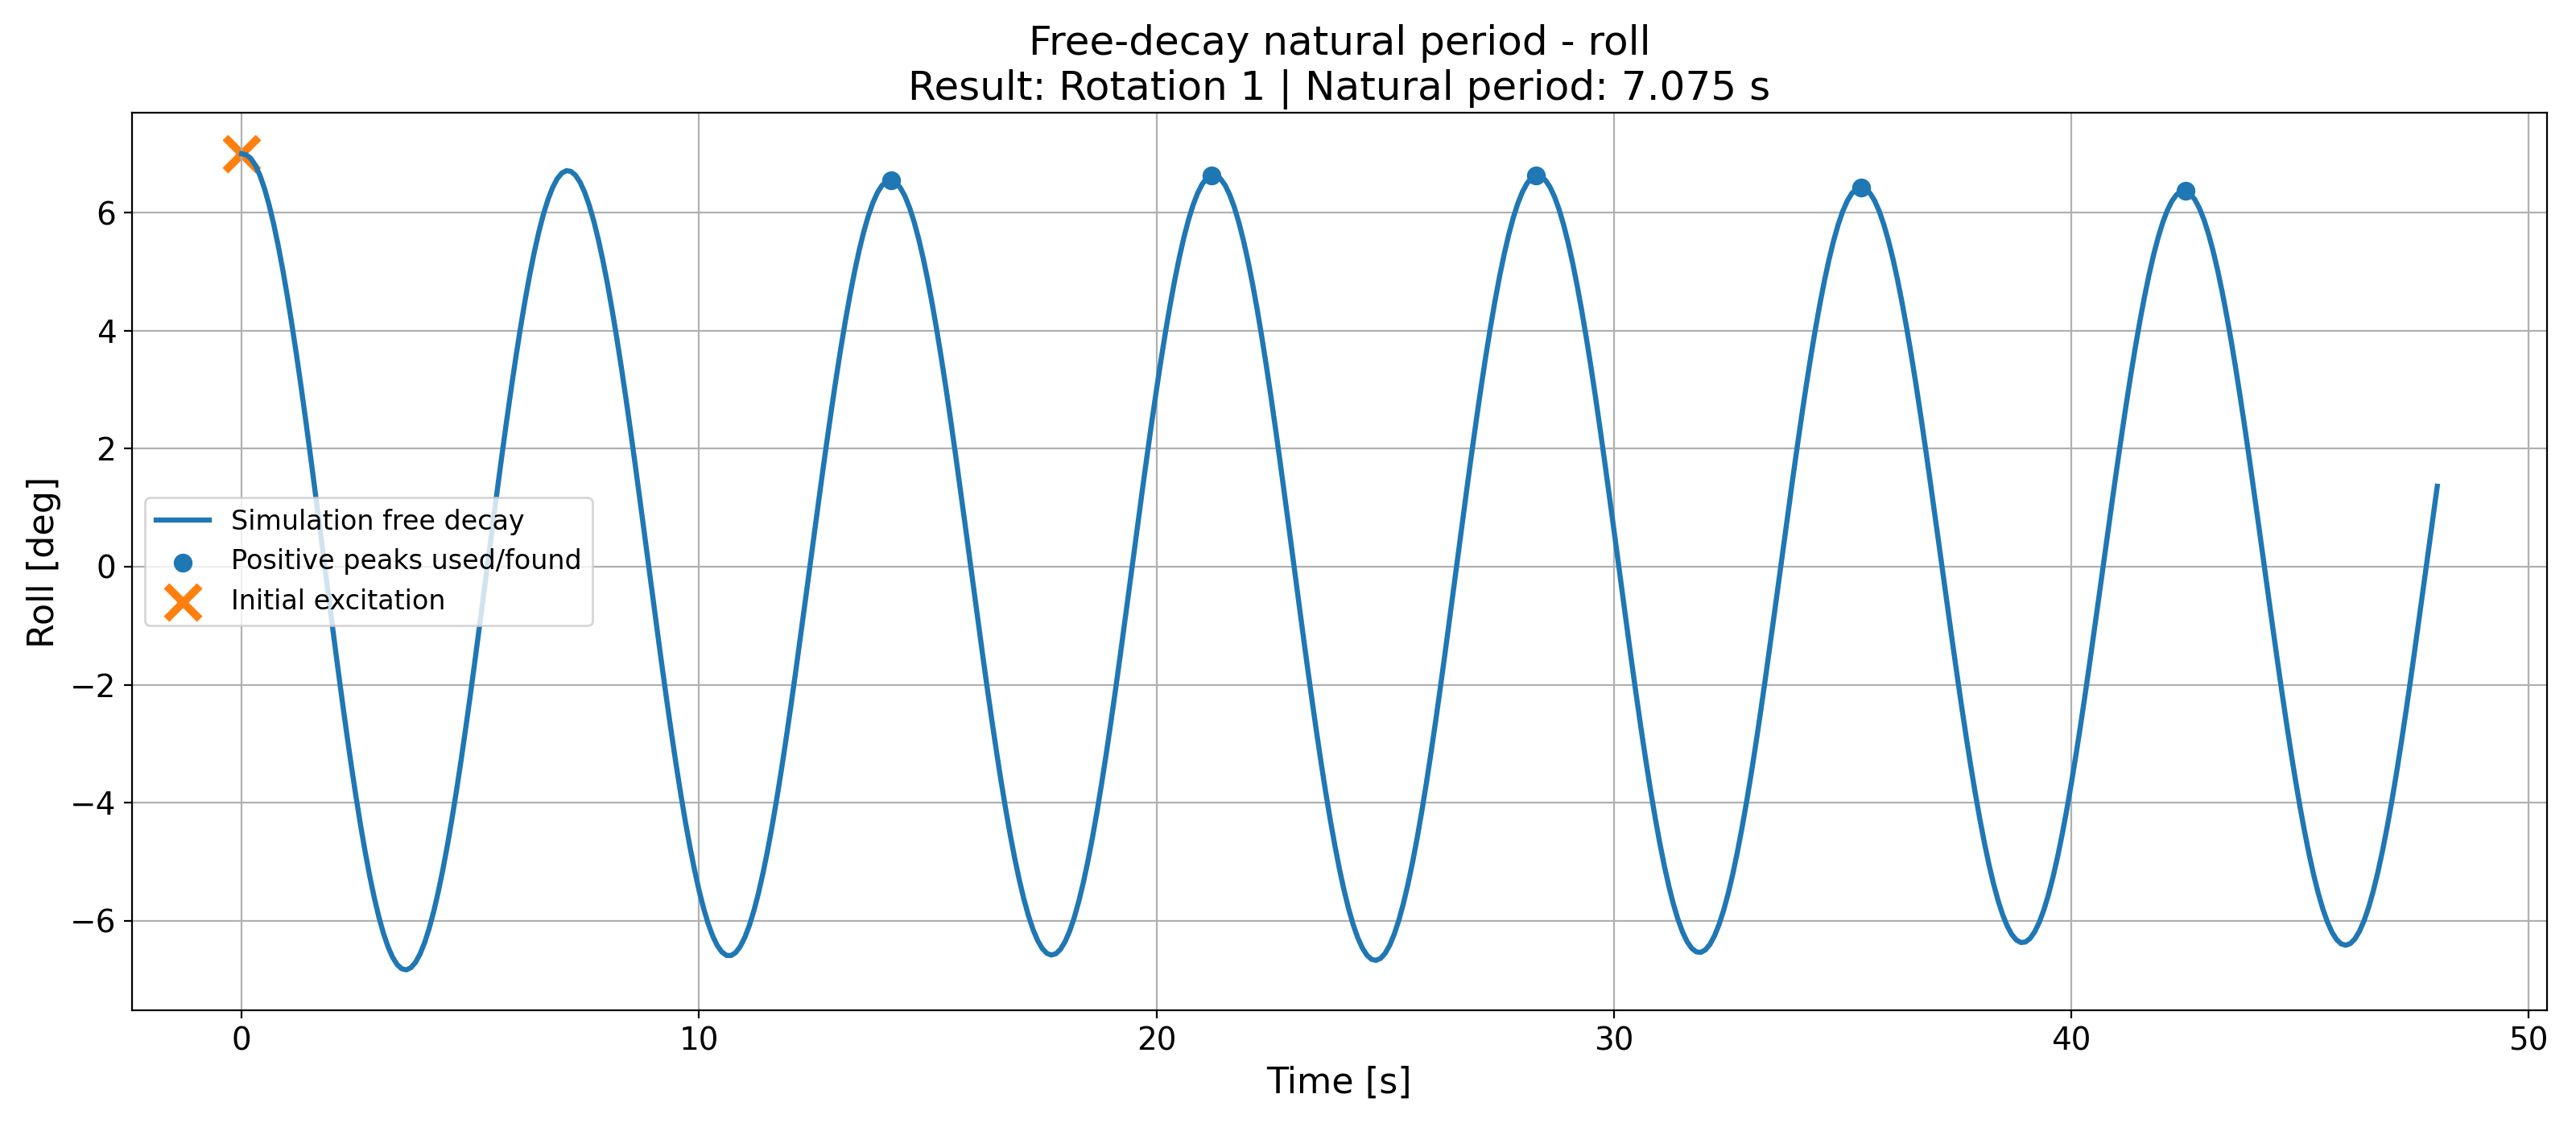

In [32]:
# Toon de opgeslagen plots in het notebook
from IPython.display import Image, display

for path in plot_paths:
    print(path.name)
    display(Image(filename=str(path)))